# **Assignment I – Zoe Mekin**
AI -Machine Learning
GitHub Repository: https://github.com/zoemekin/ML-fundamentals-2026

This notebook works with a dataset that contains information about direct marketing campaigns conducted by a Portuguese banking institution. Each row corresponds to a client who was contacted during a telemarketing campaign. The goal of the campaign
was to determine whether the client would subscribe to a term deposit. The objective is not to build the most accurate predictive model, but to carefully prepare the data so that a reliable model can be trained without methodological errors.

## **1º Identifying the prediction target**

As mentioned before, the dataset contains information about clients who were contacted during direct marketing campaigns conducted by a Portuguese banking institution. Each observation represents one client and includes demographic, financial, and campaign-related information.

Our objective is to predict whether a client will subscribe to a term deposit. In the dataset, this outcome is represented by the variable "y", which takes the values 'yes' or 'no'. Therefore, "y" is defined as the target variable.

This is a binary classification problem because the model needs to predict whether a client subscribes to a term deposit or not. In other words, each client must be classified into one of two possible outcomes: "yes" or "no".

It is also important to consider that some variables may contain information that becomes available during or after the client interaction. Such variables must be carefully evaluated in later stages to ensure that no information related to the final outcome is unintentionally used, which could lead to data leakage.

## **2º Data loading and exploration**

First, we import the libraries we need to use. Therefore, we use the "pd.set_option" to display all the columns. Sometimes when there are too many columns,pandas tend to minimize them, this way we can see all of them.

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

Now, we load the dataset into a dataframe so it´s more readable and easy to understand.

In [11]:
df = pd.read_csv("bank-additional.csv", sep=";")
df

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,487,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,346,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,227,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,17,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,58,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4114,30,admin.,married,basic.6y,no,yes,yes,cellular,jul,thu,53,1,999,0,nonexistent,1.4,93.918,-42.7,4.958,5228.1,no
4115,39,admin.,married,high.school,no,yes,no,telephone,jul,fri,219,1,999,0,nonexistent,1.4,93.918,-42.7,4.959,5228.1,no
4116,27,student,single,high.school,no,no,no,cellular,may,mon,64,2,999,1,failure,-1.8,92.893,-46.2,1.354,5099.1,no
4117,58,admin.,married,high.school,no,no,no,cellular,aug,fri,528,1,999,0,nonexistent,1.4,93.444,-36.1,4.966,5228.1,no


After the basic load of the dataset, we inspect the structure of the dataset, including its dimensions, variable types, and summary statistics.This allows us to understand what we have and what are we going to work with.

In [20]:
df.shape


(4119, 21)

The dataset contains 4,119 observations and 21 variables. This provides a sufficiently large sample size for training and evaluation.

In [21]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   str    
 2   marital         4119 non-null   str    
 3   education       4119 non-null   str    
 4   default         4119 non-null   str    
 5   housing         4119 non-null   str    
 6   loan            4119 non-null   str    
 7   contact         4119 non-null   str    
 8   month           4119 non-null   str    
 9   day_of_week     4119 non-null   str    
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   str    
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   float64
 18 

In [22]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


The statistics reveal that the mean value of `pdays` is unusually high (higher than 960 days), which is inconsistent with a realistic interpretation of “days since last contact”.

This suggests that the variable may contain special coded values rather than purely numerical information. Further investigation is required to understand its structure.

#### Identification of Numerical and Categorical Variables

We distinguish between numerical and categorical variables, since different preprocessing techniques will later be applied depending on the variable type.

In [24]:
numerical_vars = df.select_dtypes(include=["int64", "float64"]).columns
categorical_vars = df.select_dtypes(include=["object", "string"]).columns
print("Numerical variables:")
print(numerical_vars)

print("\nCategorical variables:")
print(categorical_vars)

Numerical variables:
Index(['age', 'duration', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed'],
      dtype='str')

Categorical variables:
Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome', 'y'],
      dtype='str')


The dataset contains 10 numerical variables and 11 categorical variables, including the target variable `y`. This confirms that different preprocessing strategies will be required depending on variable type.

#### Target Distribution and Class Imbalance

We now analyze the distribution of the target variable `y` in order to determine whether class imbalance is present.

In [25]:
df["y"].value_counts()

y
no     3668
yes     451
Name: count, dtype: int64

In [26]:
df["y"].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

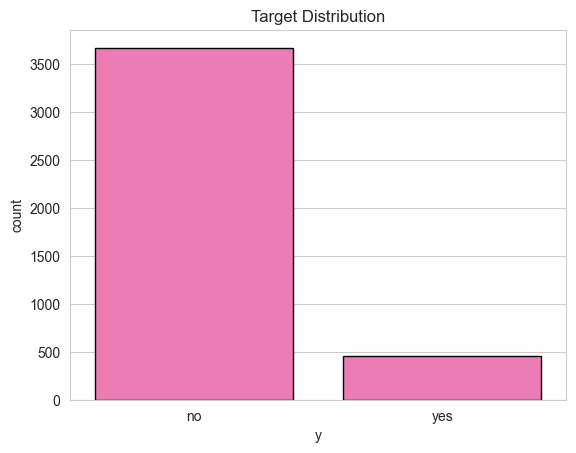

In [32]:
sns.countplot(x="y", data=df, color="#ff69b4", edgecolor="black")
plt.title("Target Distribution")
plt.show()

After analyzing the distribution of the target variable, we can determine that the dataset is imbalanced, with a significantly larger proportion of "no" outcomes compared to "yes". This imbalance can affect the model evaluation and needs to be addressed later.

#### Missing values
We check for explicit missing values (NaN) and implicit missing categories such as "unknown".

In [28]:
df.isna().sum()

for col in categorical_vars:
    if (df[col] == "unknown").sum() > 0:
        print(f"{col} contains 'unknown' values: {(df[col] == 'unknown').sum()}")

job contains 'unknown' values: 39
marital contains 'unknown' values: 11
education contains 'unknown' values: 167
default contains 'unknown' values: 803
housing contains 'unknown' values: 105
loan contains 'unknown' values: 105


Although no explicit missing values (NaN) are present in the dataset, several categorical variables contain the category "unknown", which represents implicit missing information.

Among these variables, `default` stands out with a substantially higher number of "unknown" entries compared to the others. This suggests that the bank did not consistently record clients' default status, potentially due to limited information availability rather than random omission.

In contrast, variables such as `job`, `marital`, and `education` contain relatively small proportions of "unknown" values, which may have a limited impact on the overall dataset.

Since "unknown" may carry meaningful information (for example, reflecting uncertainty or lack of reliable data) it would be inappropriate to automatically treat these entries as standard missing values without further consideration. Therefore, a careful strategy will be adopted during preprocessing to determine whether these values should be preserved as a separate category or handled differently.

#### Distribution of Selected Numerical Variables

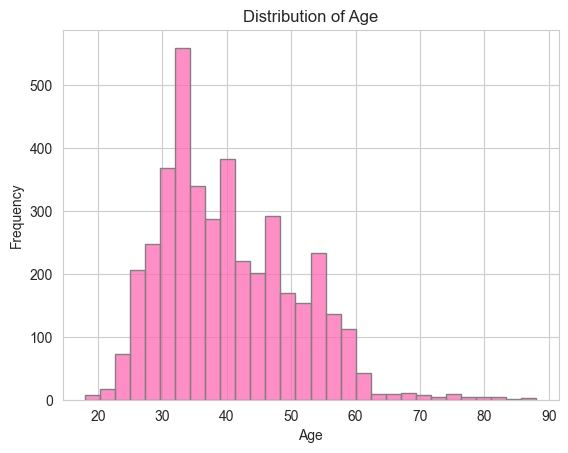

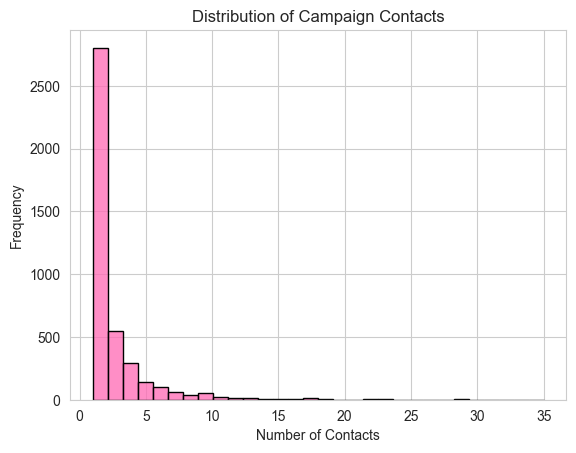

In [31]:
sns.histplot(df["age"], bins=30, color="#ff69b4", edgecolor="black")
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

sns.histplot(df["campaign"], bins=30, color="#ff69b4", edgecolor="black")
plt.title("Distribution of Campaign Contacts")
plt.xlabel("Number of Contacts")
plt.ylabel("Frequency")
plt.show()

The variables `age` and `campaign` were selected because they represent two different types of numerical features: a demographic characteristic (`age`) and a campaign-related operational variable (`campaign`). Analyzing both allows us to compare their distributional properties and assess potential preprocessing needs.

The distribution of `age` appears relatively well spread, without extreme outliers, suggesting that this variable may not require aggressive transformation.

In contrast, the variable `campaign` exhibits clear right-skewness, with most clients contacted only a few times and a small number contacted many times. Such skewness may influence model sensitivity to extreme values and could impact scaling decisions in later preprocessing stages.

Highly skewed distributions can also affect linear models, as extreme observations may disproportionately influence coefficient estimation.

#### Distribution of categorical values

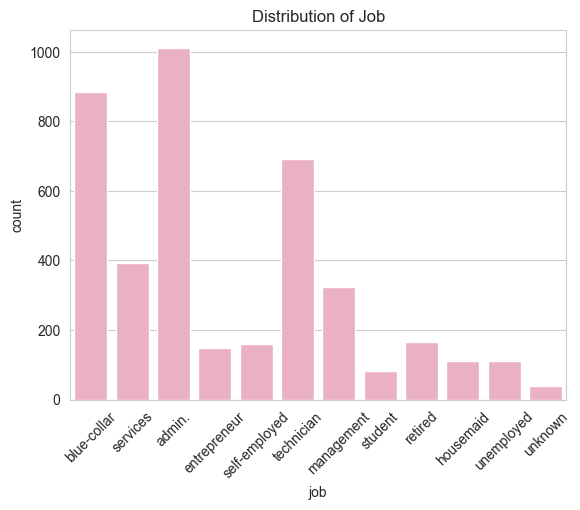

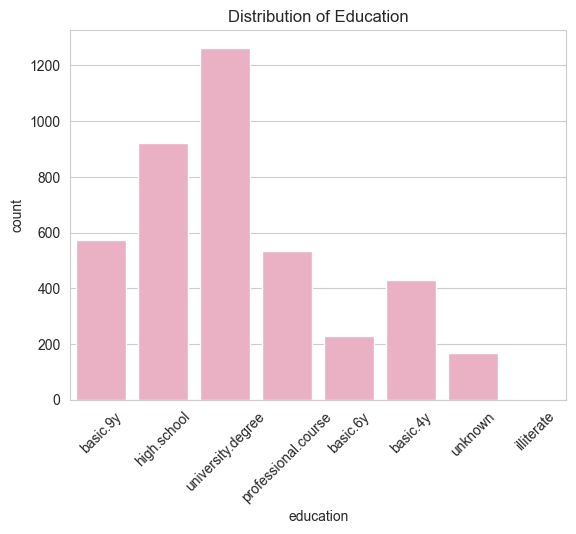

In [33]:
sns.countplot(x="job", data=df, color="#f4a6c1")
plt.xticks(rotation=45)
plt.title("Distribution of Job")
plt.show()

sns.countplot(x="education", data=df, color="#f4a6c1")
plt.xticks(rotation=45)
plt.title("Distribution of Education")
plt.show()

The variables `job` and `education` were selected because they are representative categorical features with multiple levels and potential predictive relevance. Examining them allows us to assess category balance and anticipate encoding challenges.

The categorical variables show uneven category distributions. Certain job categories and education levels are substantially more frequent than others.

Imbalanced categorical distributions may influence the model’s ability to generalize across less represented groups. Categories with very low frequency may also contribute limited predictive information or increase dimensionality once encoded.

This observation will be considered during the encoding stage.

#### Variables Requiring Special Consideration

Based on the exploratory analysis conducted above, certain variables require additional attention before proceeding to modeling.
The variable `duration` represents the length of the phone call. Since the subscription decision is typically made during the call, longer conversations may naturally be associated with a higher probability of subscription. As a result, `duration` is likely to be strongly correlated with the target variable. If this information would not realistically be available at the moment a prediction is required, including it could lead to overly optimistic performance estimates. Its role will therefore be carefully evaluated in subsequent stages.

In addition, the variable `campaign` exhibits strong right-skewness, with a small number of extreme values. Such distributions can disproportionately influence linear models and may require appropriate scaling or transformation to ensure stable parameter estimation.

At a deeper level, another variable that deserves special attention is `pdays`. From the descriptive statistics, its mean value appears unusually high, which suggests the presence of coded values rather than genuine numerical information.

In [43]:
df["pdays"].value_counts().head()

pdays
999    3959
3        52
6        42
4        14
7        10
Name: count, dtype: int64

A closer inspection reveals that the value 999 appears extremely frequently in `pdays`. According to the dataset documentation, this value indicates that the client was not previously contacted.

Therefore, 999 does not represent an actual number of days but rather a special category. Treating `pdays` as a purely numerical variable would distort summary statistics and potentially mislead the model.

This will be address later in the analysis.

## **3º  Data splitting**

The dataset is provided as a single collection of observations and does not include predefined training, validation, or test subsets. Therefore, it must be divided into these sets before applying any preprocessing steps.

The split is performed prior to imputation, encoding, scaling, feature selection, or resampling, as these operations learn information from the data. Applying them before splitting would allow information from the validation or test sets to influence the training process, resulting in data leakage.

Stratification is applied with respect to the target variable to preserve class proportions across all subsets, ensuring a consistent distribution of the outcome variable.

In [37]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=["y"])
y = df["y"]

The dataset is separated into input features (`X`) and the target variable (`y`). This ensures that the model does not inadvertently use the target during preprocessing or feature transformations.

#### First Split

In [39]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.40,
    stratify=y,
    random_state=42
)

The first split separates 60% of the data for training and reserves 40% for validation and testing. Stratification is applied to preserve the original class distribution of the target variable.

#### Second Split (Validation and Test)

In [40]:
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=42
)

The temporary subset is further divided equally into validation and test sets, resulting in a final 60/20/20 split. Stratification is again applied to maintain consistent class proportions.

In [41]:
print("Train shape:", X_train.shape)
print("Validation shape:", X_val.shape)
print("Test shape:", X_test.shape)

Train shape: (2471, 20)
Validation shape: (824, 20)
Test shape: (824, 20)


In [42]:
def show_distribution(name, y_values):
    print(f"{name} class distribution:")
    print(y_values.value_counts(normalize=True))
    print()

show_distribution("Full dataset", y)
show_distribution("Train set", y_train)
show_distribution("Validation set", y_val)
show_distribution("Test set", y_test)

Full dataset class distribution:
y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Train set class distribution:
y
no     0.890328
yes    0.109672
Name: proportion, dtype: float64

Validation set class distribution:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64

Test set class distribution:
y
no     0.890777
yes    0.109223
Name: proportion, dtype: float64



The first sanity check confirms that we have correctly partitioned the dataset into 60% for training, 20% for validation and test, respectively. The number of observations in each subset matches the intended proportions, and no data points have been lost during the splitting process. Additionally, each subset contains the same number of features, confirming that only the target variable was removed from the feature matrix.

The second sanity check verifies that stratification has been successfully applied. The class proportions of the target variable remain nearly identical across the full dataset, training, validation, and test sets. This ensures that the imbalance structure of the original dataset is preserved in all subsets.

Maintaining consistent class distributions across splits is crucial for reliable model evaluation, as differences in proportions could otherwise bias performance estimates.

## **4º Managing Missing Values**

In Section 2, both explicit and implicit missing values were identified. In particular, categorical variables containing the category "unknown" and the special coded value 999 in `pdays` were detected.

This section focuses on defining and applying appropriate preprocessing strategies. All transformations are fitted exclusively on the training set and then applied to the validation and test sets to avoid data leakage.

In [44]:
df.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
y                 0
dtype: int64

In [45]:
X_train.isna().sum()

age               0
job               0
marital           0
education         0
default           0
housing           0
loan              0
contact           0
month             0
day_of_week       0
duration          0
campaign          0
pdays             0
previous          0
poutcome          0
emp.var.rate      0
cons.price.idx    0
cons.conf.idx     0
euribor3m         0
nr.employed       0
dtype: int64

#### Handling the duration Variable

The variable `duration` represents the length of the phone call. Since the subscription decision is typically made during the call, the duration is strongly influenced by the final outcome.

Therefore, `duration` contains information that would not realistically be available at the moment a prediction is required. Including this variable would introduce temporal leakage and lead to overly optimistic performance estimates.

For this reason, `duration` is removed from the feature set.

In [46]:
X_train = X_train.drop(columns=["duration"])
X_val = X_val.drop(columns=["duration"])
X_test = X_test.drop(columns=["duration"])

#### Handling "unknown" in Categorical Variables

Several categorical variables contain the category "unknown", representing implicit missing information.

Rather than removing or imputing these entries, "unknown" will be preserved as a separate category. This decision is justified because the absence of information may itself carry predictive value and does not necessarily represent random missingness.

#### Handling the pdays Variable

The variable `pdays` contains a large number of values equal to 999, which according to the dataset documentation indicates that the client was not previously contacted.

The value 999 does not represent an actual number of days, but rather a coded category. Treating it as a numerical value would distort summary statistics and potentially mislead the model.

To address this issue, a new binary variable is created to indicate whether the client was previously contacted. The value 999 is then replaced with NaN in `pdays`, allowing it to be treated appropriately during imputation.

In [48]:
X_train["previously_contacted"] = X_train["pdays"].apply(lambda x: 0 if x == 999 else 1)

X_train["pdays"] = X_train["pdays"].replace(999, np.nan)

In [47]:
X_val["previously_contacted"] = X_val["pdays"].apply(lambda x: 0 if x == 999 else 1)
X_val["pdays"] = X_val["pdays"].replace(999, np.nan)

X_test["previously_contacted"] = X_test["pdays"].apply(lambda x: 0 if x == 999 else 1)
X_test["pdays"] = X_test["pdays"].replace(999, np.nan)

#### Verify Missing Values

In [49]:
X_train.isna().sum()

age                        0
job                        0
marital                    0
education                  0
default                    0
housing                    0
loan                       0
contact                    0
month                      0
day_of_week                0
campaign                   0
pdays                   2368
previous                   0
poutcome                   0
emp.var.rate               0
cons.price.idx             0
cons.conf.idx              0
euribor3m                  0
nr.employed                0
previously_contacted       0
dtype: int64

After replacing the coded value 999 with NaN, the variable `pdays` now contains missing values corresponding to clients who were not previously contacted.

These missing values are structural rather than random, as they indicate the absence of previous contact rather than missing information.

## **5º Encoding Categorical Variables**

As we know, Logistic regresion requires numerical input features. Therefore, we need to transform the categorical values into numerical representations before we train the model. All econding steps are fitted on the training set and then applied to the validation and test. This way, we prevent data leakage.

In [52]:
categorical_cols = X_train.select_dtypes(include=["object", "string"]).columns
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='str')

In [53]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

#### Fit on the training set

In [59]:
encoder.fit(X_train[categorical_cols])

,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a :class:`scipy.sparse.csr_matrix`,i.e. a sparse matrix in ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",False
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide `.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide `.",None
,"max_cate

#### Transforming all sets

In [60]:
X_train_encoded = encoder.transform(X_train[categorical_cols])
X_val_encoded = encoder.transform(X_val[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

#### Recovering column names

In [61]:
encoded_feature_names = encoder.get_feature_names_out(categorical_cols)

#### Convert to dataframe

In [62]:
X_train_encoded = pd.DataFrame(
    X_train_encoded,
    columns=encoded_feature_names,
    index=X_train.index
)

X_val_encoded = pd.DataFrame(
    X_val_encoded,
    columns=encoded_feature_names,
    index=X_val.index
)

X_test_encoded = pd.DataFrame(
    X_test_encoded,
    columns=encoded_feature_names,
    index=X_test.index
)

#### Remove Original Categorical Columns

In [63]:
X_train_num = X_train.drop(columns=categorical_cols)
X_val_num = X_val.drop(columns=categorical_cols)
X_test_num = X_test.drop(columns=categorical_cols)

#### Combine Numerical And Encoded Features

In [65]:
X_train_final = pd.concat([X_train_num, X_train_encoded], axis=1)
X_val_final = pd.concat([X_val_num, X_val_encoded], axis=1)
X_test_final = pd.concat([X_test_num, X_test_encoded], axis=1)

In this section, categorical variables were transformed into numerical representations using One-Hot Encoding. This step is necessary because Logistic Regression and most machine learning algorithms require numerical input features.

The encoder was fitted exclusively on the training set to ensure that no information from the validation or test sets influenced the transformation process. This prevents data leakage and guarantees a fair evaluation of model performance.

Each categorical variable was expanded into multiple binary columns, one for each category. The original categorical columns were then removed and replaced with their encoded versions. As a result, all features in the dataset are now numerical and suitable for subsequent preprocessing steps such as scaling and model training.

Although the variable `education` has an ordinal interpretation (e.g., basic education < high school < university degree), it was treated as nominal and encoded using One-Hot Encoding. This decision avoids imposing an artificial linear relationship between education levels, which may not reflect the true effect of education on subscription probability.



### **6º Feature Scaling**

After encoding, all features are numerical. However, numerical variables may have very different ranges and magnitudes.
Feature scaling is applied to ensure that variables contribute proportionally to the model and to improve the stability of gradient-based optimization.
Scaling parameters are estimated exclusively on the training set and then applied to the validation and test sets to prevent data leakage.

#### Identify numerical columns

In [66]:
numerical_cols = X_train_final.select_dtypes(include=["int64", "float64"]).columns
numerical_cols

Index(['age', 'campaign', 'pdays', 'previous', 'emp.var.rate',
       'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed',
       'previously_contacted', 'job_admin.', 'job_blue-collar',
       'job_entrepreneur', 'job_housemaid', 'job_management', 'job_retired',
       'job_self-employed', 'job_services', 'job_student', 'job_technician',
       'job_unemployed', 'job_unknown', 'marital_divorced', 'marital_married',
       'marital_single', 'marital_unknown', 'education_basic.4y',
       'education_basic.6y', 'education_basic.9y', 'education_high.school',
       'education_illiterate', 'education_professional.course',
       'education_university.degree', 'education_unknown', 'default_no',
       'default_unknown', 'default_yes', 'housing_no', 'housing_unknown',
       'housing_yes', 'loan_no', 'loan_unknown', 'loan_yes',
       'contact_cellular', 'contact_telephone', 'month_apr', 'month_aug',
       'month_dec', 'month_jul', 'month_jun', 'month_mar', 'month_may',
       'mo

As we have computed the encoding, all the variables are now numerical.

#### Scaler

In [68]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

We know that the scaler is computing this formula: z= (x - μ)/σ.


#### Fit only on the train set

In [69]:
scaler.fit(X_train_final)

,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


In [70]:
X_train_scaled = scaler.transform(X_train_final)
X_val_scaled = scaler.transform(X_val_final)
X_test_scaled = scaler.transform(X_test_final)

#### Convert back to dataframe

In [75]:
X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X_train_final.columns,
    index=X_train_final.index
)

X_val_scaled = pd.DataFrame(
    X_val_scaled,
    columns=X_val_final.columns,
    index=X_val_final.index
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X_test_final.columns,
    index=X_test_final.index
)


In [76]:
X_train_scaled.head()

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
1802,-0.787502,0.906300,NaN,-0.360455,0.855210,0.586888,-0.487041,0.784840,0.851123,-0.208558,-0.577506,-0.506820,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,2.187895,-0.153663,-0.090332,-0.362506,0.811412,-0.620556,-0.053300,-0.334007,-0.235652,2.569645,-0.554443,-0.020121,-0.387779,-0.665839,-0.209613,0.499241,-0.498608,-0.020121,1.125599,-0.15088,-1.076141,0.484010,-0.15088,-0.448625,0.759538,-0.759538,-0.237559,-0.425636,-0.08073,2.275412,-0.378052,-0.101098,-0.726081,-0.350245,-0.140749,-0.126634,2.093667,-0.513120,-0.51312,-0.506189,-0.489734,-0.363220,0.424309,-0.193297
1114,-1.078343,-0.586429,NaN,-0.360455,-1.186553,-1.161368,-1.237687,-1.327822,-0.891652,-0.208558,-0.577506,1.973086,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,-1.232420,1.611458,-0.053300,-0.334007,-0.235652,2.569645,-0.554443,-0.020121,-0.387779,-0.665839,-0.209613,0.499241,-0.498608,-0.020121,1.125599,-0.15088,-1.076141,0.484010,-0.15088,-0.448625,0.759538,-0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,1.377256,-0.350245,-0.140749,-0.126634,-0.477631,-0.513120,-0.51312,-0.506189,2.041925,-0.363220,0.424309,-0.193297
2902,-1.756972,-0.213247,NaN,4.941233,-0.739917,1.066165,0.628205,-1.556761,-2.722241,-0.208558,1.731584,-0.506820,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,-1.232420,1.611458,-0.053300,-0.334007,-0.235652,-0.389159,-0.554443,-0.020121,-0.387779,1.501865,-0.209613,0.499241,-0.498608,-0.020121,-0.888416,-0.15088,0.929247,0.484010,-0.15088,-0.448625,0.759538,-0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,-0.726081,-0.350245,-0.140749,7.896770,-0.477631,1.948861,-0.51312,-0.506189,-0.489734,2.753155,-2.356773,-0.193297
2547,-0.593609,-0.213247,NaN,1.406775,-1.186553,-1.161368,-1.237687,-1.291674,-0.891652,-0.208558,-0.577506,-0.506820,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,2.987255,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,-1.232420,-0.620556,18.761663,-0.334007,-0.235652,-0.389159,1.803611,-0.020121,-0.387779,-0.665839,-0.209613,0.499241,-0.498608,-0.020121,-0.888416,-0.15088,0.929247,-2.066073,-0.15088,2.229035,0.759538,-0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,1.377256,-0.350245,-0.140749,-0.126634,-0.477631,-0.513120,-0.51312,1.975545,-0.489734,2.753155,-2.356773,-0.193297
1659,1.442277,-0.586429,NaN,1.406775,-1.186553,-1.161368,-1.237687,-1.327822,-0.891652,-0.208558,-0.577506,1.973086,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,2.758579,-1.232420,-0.620556,-0.053300,2.993946,-0.235652,-0.389159,-0.554443,-0.020121,-0.387779,-0.665839,-0.209613,-2.003040,2.005582,-0.020121,1.125599,-0.15088,-1.076141,0.484010,-0.15088,-0.448625,0.759538,-0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,1.377256,-0.350245,-0.140749,-0.126634,-0.477631,-0.513120,-0.51312,-0.506189,2.041925,2.753155,-2.356773,-0.193297


The preview of the scaled training set confirms that all features are numerical and standardized. Values are centered around zero, as expected after applying StandardScaler.

In [77]:
X_train_scaled.describe().loc[["mean", "std"]]

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,previously_contacted,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_no,default_unknown,default_yes,housing_no,housing_unknown,housing_yes,loan_no,loan_unknown,loan_yes,contact_cellular,contact_telephone,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent,poutcome_success
mean,-1.811582e-16,-4.744620e-17,-1.724618e-17,-1.150211e-17,2.012869e-17,-8.875314e-15,4.370801e-16,-4.744620e-17,1.058266e-14,5.751054e-18,-2.012869e-17,-2.012869e-17,-1.437764e-17,3.450632e-17,2.587974e-17,2.300422e-17,2.875527e-18,-4.313291e-17,2.731751e-17,-2.012869e-17,2.480142e-17,1.437764e-17,8.626581e-18,-5.175949e-17,3.450632e-17,-2.516086e-17,-5.751054e-17,1.725316e-17,6.038607e-17,0.000000,8.626581e-18,-3.450632e-17,2.444198e-17,2.300422e-17,1.754072e-16,1.150211e-17,1.725316e-17,-8.626581e-18,-1.581540e-17,-3.019303e-17,9.776792e-17,-1.581540e-17,1.437764e-17,-4.097626e-17,-9.920568e-17,-3.450632e-17,2.875527e-17,-4.097626e-17,-2.875527e-17,6.901265e-17,-4.600843e-17,6.038607e-17,4.744620e-17,5.032172e-17,7.188818e-19,-1.006434e-17,3.881962e-17,3.738185e-17,-3.163080e-17,-3.594409e-18,-2.731751e-17,-1.063945e-16,3.881962e-17
std,1.000202e+00,1.000202e+00,1.004890e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00,1.000202e+00


The summary statistics confirm that the scaled features have mean approximately zero and standard deviation close to one, as expected after standardization.

The scaling process follows the same  structure used during encoding. First, the scaler is fitted exclusively on the training set to learn the distributional parameters (mean and standard deviation). Then, the learned transformation is applied to the validation and test sets without refitting.
 This consistent procedure ensures that no information from the validation or test sets influences the training process, maintaining strict separation between data used for learning and data used for evaluation.

After scaling, all numerical variables are standardized with mean zero and unit variance. This prevents features with larger magnitudes from dominating the optimization process and improves the stability of Logistic Regression training.

## **7º Feature Selection**

Feature selection is performed to reduce redundancy, remove non-informative features, and improve model stability.

In the context of Logistic Regression, highly redundant or low-variance features may lead to unstable coefficient estimates and reduced interpretability. Additionally, removing unnecessary variables helps simplify the model and reduce the risk of overfitting.

All feature selection decisions are made exclusively using the training set to prevent data leakage. The selected features are then applied consistently to the validation and test sets.

#### Low variance filtering

In [78]:
from sklearn.feature_selection import VarianceThreshold

variance_selector = VarianceThreshold(threshold=0.01)

variance_selector.fit(X_train_scaled)

variance_mask = variance_selector.get_support()

X_train_var = X_train_scaled.loc[:, variance_mask]
X_val_var = X_val_scaled.loc[:, variance_mask]
X_test_var = X_test_scaled.loc[:, variance_mask]

print("Original number of features:", X_train_scaled.shape[1])
print("Remaining after variance filtering:", X_train_var.shape[1])

Original number of features: 63
Remaining after variance filtering: 63


Low-variance features contribute little information to the model, as they show minimal variability across observations. Removing them reduces dimensionality and may improve numerical stability without sacrificing predictive power.

After applying the variance threshold, the number of features remained unchanged. This indicates that no feature exhibited extremely low variability across observations. Therefore, all features retain sufficient variance to potentially contribute meaningful information to the model.

#### Correlation Analysis

In [79]:
import numpy as np

corr_matrix = X_train_var.corr().abs()

upper_triangle = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr_features = [
    column for column in upper_triangle.columns
    if any(upper_triangle[column] > 0.9)
]

high_corr_features

['euribor3m',
 'nr.employed',
 'default_unknown',
 'housing_yes',
 'loan_unknown',
 'loan_yes',
 'contact_telephone',
 'poutcome_success']

In [80]:
X_train_sel = X_train_var.drop(columns=high_corr_features)
X_val_sel = X_val_var.drop(columns=high_corr_features)
X_test_sel = X_test_var.drop(columns=high_corr_features)

print("Remaining features after correlation filtering:", X_train_sel.shape[1])

Remaining features after correlation filtering: 55


The correlation analysis identified several features with absolute correlation values above the selected threshold of 0.9. These include macroeconomic indicators such as `euribor3m` and `nr.employed`, as well as multiple one-hot encoded categorical variables (e.g., `default_unknown`, `housing_yes`, `loan_yes`, `contact_telephone`, `poutcome_success`).

A threshold of 0.9 was chosen to identify only very strong linear relationships, ensuring that only highly redundant features are removed. Lower thresholds (e.g., 0.8) could lead to the removal of variables that still provide complementary information.

Highly correlated features introduce redundancy and may cause multicollinearity, particularly in linear models such as Logistic Regression. Multicollinearity can destabilize coefficient estimates, inflate variance, and reduce interpretability without improving predictive performance. In this case, the strong correlation between `euribor3m` and `nr.employed` likely reflects shared macroeconomic trends. Similarly, correlations among one-hot encoded variables may arise due to complementary category structures.

To reduce redundancy and improve numerical stability, the identified highly correlated features were removed from the dataset.

Beyond statistical filtering, conceptual reasoning is also applied. The variable `duration` was previously removed due to temporal leakage concerns.

In [81]:
X_train_sel
X_val_sel
X_test_sel

,age,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,previously_contacted,job_admin.,job_blue-collar,job_entrepreneur,job_housemaid,job_management,job_retired,job_self-employed,job_services,job_student,job_technician,job_unemployed,job_unknown,marital_divorced,marital_married,marital_single,marital_unknown,education_basic.4y,education_basic.6y,education_basic.9y,education_high.school,education_illiterate,education_professional.course,education_university.degree,education_unknown,default_no,default_yes,housing_no,housing_unknown,loan_no,contact_cellular,month_apr,month_aug,month_dec,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,day_of_week_fri,day_of_week_mon,day_of_week_thu,day_of_week_tue,day_of_week_wed,poutcome_failure,poutcome_nonexistent
3393,-0.205821,0.159935,NaN,-0.360455,0.663795,0.716514,0.864122,-0.208558,-0.577506,-0.506820,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,2.187895,-0.153663,-0.090332,-0.362506,-1.232420,1.611458,-0.0533,-0.334007,-0.235652,-0.389159,-0.554443,-0.020121,-0.387779,1.501865,-0.209613,0.499241,-0.020121,-0.888416,-0.15088,-2.066073,-1.316589,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,1.377256,-0.350245,-0.140749,-0.126634,-0.477631,-0.513120,1.948861,-0.506189,-0.489734,-0.363220,0.424309
966,-0.787502,-0.586429,NaN,1.406775,-0.101866,-0.637744,-0.336912,-0.208558,-0.577506,-0.506820,5.085145,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,0.811412,-0.620556,-0.0533,-0.334007,-0.235652,-0.389159,1.803611,-0.020121,-0.387779,-0.665839,-0.209613,0.499241,-0.020121,-0.888416,-0.15088,0.484010,0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,-0.726081,2.855145,-0.140749,-0.126634,-0.477631,-0.513120,-0.513120,-0.506189,2.041925,2.753155,-2.356773
1183,-0.593609,-0.213247,0.058928,1.406775,-0.101866,-0.637744,-0.336912,4.794819,-0.577506,-0.506820,-0.196651,-0.174476,3.435565,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,-1.232420,1.611458,-0.0533,-0.334007,-0.235652,-0.389159,1.803611,-0.020121,-0.387779,-0.665839,-0.209613,0.499241,-0.020121,-0.888416,-0.15088,-2.066073,0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,-0.726081,2.855145,-0.140749,-0.126634,-0.477631,-0.513120,-0.513120,-0.506189,2.041925,-0.363220,-2.356773
2589,0.375861,0.159935,NaN,-0.360455,0.663795,0.716514,0.864122,-0.208558,-0.577506,1.973086,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,0.811412,-0.620556,-0.0533,-0.334007,-0.235652,-0.389159,1.803611,-0.020121,-0.387779,-0.665839,-0.209613,-2.003040,-0.020121,-0.888416,-0.15088,0.484010,-1.316589,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,1.377256,-0.350245,-0.140749,-0.126634,-0.477631,1.948861,-0.513120,-0.506189,-0.489734,-0.363220,0.424309
54,-0.690555,-0.586429,NaN,-0.360455,-1.186553,-1.161368,-1.237687,-0.208558,1.731584,-0.506820,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,-1.232420,1.611458,-0.0533,-0.334007,-0.235652,-0.389159,-0.554443,-0.020121,-0.387779,1.501865,-0.209613,0.499241,-0.020121,-0.888416,-0.15088,0.484010,0.759538,-0.237559,-0.425636,-0.08073,-0.439481,-0.378052,-0.101098,1.377256,-0.350245,-0.140749,-0.126634,-0.477631,-0.513120,1.948861,-0.506189,-0.489734,-0.363220,0.424309
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3491,0.278914,-0.586429,NaN,-0.360455,-0.101866,-0.637744,-0.336912,-0.208558,-0.577506,1.973086,-0.196651,-0.174476,-0.291073,-0.202137,-0.198861,-0.334755,-0.137728,-0.457060,-0.153663,-0.090332,-0.362506,0.811412,-0.620556,-0.0533,-0.334007,-0.235652,2.569645,-0.554443,-0.020121,-0.387779,-0.665839,-0

## **8º Addressing Class Imbalance**

The target variable exhibits a clear class imbalance, with a significantly larger proportion of clients who did not subscribe compared to those who did.

Class imbalance may bias model performance, particularly when using accuracy as the primary evaluation metric. A model predicting only the majority class could achieve high accuracy while failing to correctly identify the minority class. Therefore, strategies to address class imbalance are considered to ensure fair and meaningful model evaluation.

In [82]:
majority_class = y_train.mode()[0]

baseline_accuracy = (y_val == majority_class).mean()

print("Majority class:", majority_class)
print("Baseline validation accuracy:", baseline_accuracy)

Majority class: no
Baseline validation accuracy: 0.8907766990291263


The **Zero Rule baseline** predicts the majority class ("no") for all observations, achieving an accuracy of approximately 89%.

This result highlights the strong class imbalance present in the dataset. A naive classifier that ignores all features can already achieve high accuracy by predicting the majority class. Therefore, accuracy alone is not an adequate performance metric in this context. Additional metrics such as precision and recall will be considered to properly evaluate the model's ability to identify the minority class ("yes").

In [91]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="constant", fill_value=0)

X_train_imp = pd.DataFrame(
    imputer.fit_transform(X_train_sel),
    columns=X_train_sel.columns,
    index=X_train_sel.index
)

X_val_imp = pd.DataFrame(
    imputer.transform(X_val_sel),
    columns=X_val_sel.columns,
    index=X_val_sel.index
)

X_test_imp = pd.DataFrame(
    imputer.transform(X_test_sel),
    columns=X_test_sel.columns,
    index=X_test_sel.index
)

# Sanity check: confirm no NaNs remain
print("NaNs in X_train_imp:", X_train_imp.isna().sum().sum())

NaNs in X_train_imp: 0


SMOTE does not support missing values. Since `pdays` was converted to NaN to represent clients with no previous contact, the training data contains NaNs.

To allow resampling, missing values are imputed **after splitting** and **before applying SMOTE**. The imputation is fitted only on the training set and then applied to validation and test sets to prevent leakage. Because the missingness in `pdays` is structural and is already captured by `previously_contacted`, missing `pdays` values are imputed with a constant placeholder value (0).

In [92]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_balanced, y_train_balanced = smote.fit_resample(X_train_imp, y_train)

y_train_balanced.value_counts(normalize=True)

y
no     0.5
yes    0.5
Name: proportion, dtype: float64

After applying SMOTE, the training set is now perfectly balanced, with both classes representing 50% of the observations.

SMOTE was selected instead of simple random oversampling because it generates synthetic examples of the minority class rather than duplicating existing observations. This helps reduce the risk of overfitting while improving the model’s ability to learn decision boundaries for the minority class.

Given the significant class imbalance observed in the original dataset, resampling the training set allows the model to better capture patterns associated with subscription ("yes"), which would otherwise be underrepresented. Importantly, the validation and test sets remain unchanged, preserving their original class distribution and ensuring fair and realistic model evaluation.

## **9º Logistic Regression Model**

A Logistic Regression model is trained as a consistency check of the data preparation pipeline. The objective is not to maximize predictive performance, but to verify that preprocessing decisions have been applied correctly.
Model performance is evaluated on the validation set using multiple metrics to account for class imbalance.

#### Training the model

In [93]:
from sklearn.linear_model import LogisticRegression

# Initialize model
log_reg = LogisticRegression(max_iter=1000, random_state=42)

# Train on balanced training set
log_reg.fit(X_train_balanced, y_train_balanced)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multi

#### Predicting on validation set

In [94]:
# Predict on validation set
y_val_pred = log_reg.predict(X_val_imp)

# Predicted probabilities (optional but useful)
y_val_proba = log_reg.predict_proba(X_val_imp)[:, 1]

#### Evaluating performance

In [95]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix

accuracy = accuracy_score(y_val, y_val_pred)
precision = precision_score(y_val, y_val_pred, pos_label="yes")
recall = recall_score(y_val, y_val_pred, pos_label="yes")

print("Validation Accuracy:", accuracy)
print("Validation Precision:", precision)
print("Validation Recall:", recall)

conf_matrix = confusion_matrix(y_val, y_val_pred)
conf_matrix

Validation Accuracy: 0.8058252427184466
Validation Precision: 0.30337078651685395
Validation Recall: 0.6


array([[610, 124],
       [ 36,  54]])

The Logistic Regression model was trained on the SMOTE-balanced training set and evaluated on the original (unbalanced) validation set.

The validation accuracy (≈ 0.81) is lower than the Zero Rule baseline (≈ 0.89). However, this decrease in accuracy is expected due to the class imbalance in the dataset. The baseline model simply predicts the majority class ("no") for all observations, achieving high accuracy while failing to identify subscribers. More importantly, the model achieves a recall of 0.60 for the minority class ("yes"), meaning that it correctly identifies 60% of actual subscribers. This represents a substantial improvement over the baseline, which would have a recall of 0 for the minority class. The precision value (≈ 0.30) indicates that approximately 30% of predicted subscriptions are correct. This reflects the trade-off introduced by SMOTE: improving minority detection (recall) at the cost of increased false positives.

Overall, the model demonstrates improved ability to detect the minority class compared to the naive baseline, even though overall accuracy decreases. This highlights why accuracy alone is not an appropriate evaluation metric in imbalanced classification problems.

## **10º Order justification**

The order of tasks in this notebook was deliberately structured to prevent data leakage and ensure methodological rigor.

First, the target variable was clearly identified and its prediction context analyzed. This ensured that only variables available at prediction time were considered valid predictors.

Next, exploratory data analysis was performed to understand variable types, detect implicit missing values, assess class imbalance, and identify potentially problematic features such as `duration` and `pdays`.

The dataset was then split into training, validation, and test sets before applying any preprocessing transformations. This step was critical to avoid preprocessing leakage, as transformations such as encoding, scaling, feature selection, and resampling learn information from the data.

All preprocessing steps; including handling missing values, encoding categorical variables, scaling numerical features, feature selection, and applying SMOTE, were fitted exclusively on the training set and subsequently applied to the validation and test sets.

Finally, Logistic Regression was trained on the processed and balanced training set and evaluated on the original validation distribution to obtain a fair performance estimate.

Any deviation from this order; for example, applying scaling or SMOTE before splitting, would have introduced information from the validation or test sets into the training process, leading to overly optimistic and invalid performance estimates.